<a href="https://colab.research.google.com/github/ch21an/my-first-repository/blob/main/Activation_Loss_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🏁 도전 1: "왜 층이 깊어지면 Sigmoid가 안 될까?" (MNIST 데이터)
0~9까지의 손글씨 숫자를 분류하는 예제입니다.

데이터: MNIST (TensorFlow에서 기본 제공)

실습 미션:

Case A (실패 유도): 은닉층을 10층 이상 깊게 쌓고, 활성화 함수를 모두 Sigmoid로 설정하세요.

Case B (성공): 똑같은 구조에서 활성화 함수만 ReLU로 바꿔보세요.


관전 포인트: 층이 깊어질수록 Gradient Vanishing(기울기 소실) 현상 때문에 Sigmoid 모델의 Loss가 줄어들지 않는 현상을 확인할 수 있습니다. =>> 확인!!


🏁 도전 2: "암 진단 모델의 손실 함수 선택" (위스콘신 암 데이터)
환자의 상태를 보고 악성(1)인지 양성(0)인지 판단하는 이진 분류 문제입니다.

데이터: Breast Cancer Dataset (Scikit-learn 제공)

실습 미션:

Case A: 출력층 Sigmoid + 손실 함수 MSE.

Case B: 출력층 Sigmoid + 손실 함수 Binary Cross-Entropy(BCE).


관전 포인트: BCE를 썼을 때가 MSE보다 초반 학습 속도가 훨씬 빠르고, 정답에 대한 '확신'이 강해지는 것을 Loss 그래프의 경사도로 체감할 수 있습니다.

🏁 도전 3: "불균형 데이터와 재현율(Recall)의 함정" (신용카드 사기 탐지)
대부분의 거래는 정상이지만, 아주 극소수의 사기 거래를 찾아내야 합니다.

데이터: Credit Card Fraud Detection (Kaggle 데이터)

실습 미션:


조합: Softmax + Categorical Cross-Entropy + RMSProp.

분석: 모델의 Accuracy(정확도)는 99%가 넘는데, 실제 사기범을 잡는 Recall(재현율)은 왜 낮은지 분석해 보세요.


관전 포인트: 데이터가 불균형할 때 단순 정확도 그래프만 보는 것이 얼마나 위험한지, 왜 Loss 그래프와 재현율을 동시에 봐야 하는지 깨닫게 됩니다.

💡 실습 팁
각 실험을 할 때마다 Train Loss와 Validation Loss 그래프를 그려보세요.

두 선이 같이 내려가면 정상 학습.

Train Loss는 내려가는데 Validation Loss가 다시 올라가면 과적합(Overfitting).


-------------------------


지금 질문자님이 공부하신 Sigmoid, Softmax, ReLU / BCE, CCE, MSE / SGD, Adam은 전체 딥러닝 생태계의 80% 이상을 차지하는 근간입니다.

입문 단계: 지금 알고 계신 조합들로 다양한 데이터를 돌려보며 '어떤 상황에 어떤 그래프가 그려지는지' 감을 잡는 것이 훨씬 중요합니다.

심화 단계: 모델 성능이 정체될 때 "Leaky ReLU로 바꿔볼까?", "AdamW를 써볼까?" 하며 하나씩 추가해 나가는 것이 정석입니다.


##도전 1

###도전 1-실패유도


In [ ]:
!pip install tensorflow

In [ ]:
# 데이터 불러오기
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train, t_train), (x_test, t_test)= mnist.load_data()

# 데이터 전처리- 이미지 데이터이므로 정규화, 원핫 인코딩
# 1) 정규화
x_train= x_train-0.0/255.0-0.0
x_test= x_test-0.0/255.0-0.0

#2) 원핫 인코딩
t_train=tf.keras.utils.to_categorical(t_train, num_classes=10)
t_test=tf.keras.utils.to_categorical(t_test, num_classes=10)


# 모델 구축
model= tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(256,activation='sigmoid')) # GPU 구조상 의 제곱수로 연산을 해주는게 효율적.
model.add(tf.keras.layers.Dense(256,activation='sigmoid'))
model.add(tf.keras.layers.Dense(128,activation='sigmoid'))
model.add(tf.keras.layers.Dense(128,activation='sigmoid'))
model.add(tf.keras.layers.Dense(64,activation='sigmoid'))
model.add(tf.keras.layers.Dense(64,activation='sigmoid'))
model.add(tf.keras.layers.Dense(32,activation='sigmoid'))
model.add(tf.keras.layers.Dense(32,activation='sigmoid'))
model.add(tf.keras.layers.Dense(16,activation='sigmoid'))

model.add(tf.keras.layers.Dense(10,activation='softmax')) #처음 할때는 마지막 활성화 함수까지 sigmoid 해버림
model.summary()

#모델 컴파일
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4),  #Adam으로 옵티마이저 했다가 loss, accuracy 다 줄어서 바꿈(SGD).
              loss='categorical_crossentropy',
              metrics=['accuracy', 'recall', 'precision'])


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))
(array([0., 1.]), array([90000, 10000]))


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,410 (1.27 MB)

 Trainable params: 332,410 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#도전 1-실패-2

#모델 학습
hist=model.fit(x_train, t_train, validation_split=0.3, epochs=30)


Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.0901 - loss: 2.6654 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0909 - val_loss: 2.6533 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.0901 - loss: 2.6222 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0909 - val_loss: 2.6122 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.0901 - loss: 2.5843 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0909 - val_loss: 2.5761 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.0901 - loss: 2.5510 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0909 - val_loss: 2.5444 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.0901 - loss: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1009 - loss: 2.4315 - precision: 0.0000e+00 - recall: 0.0000e+00


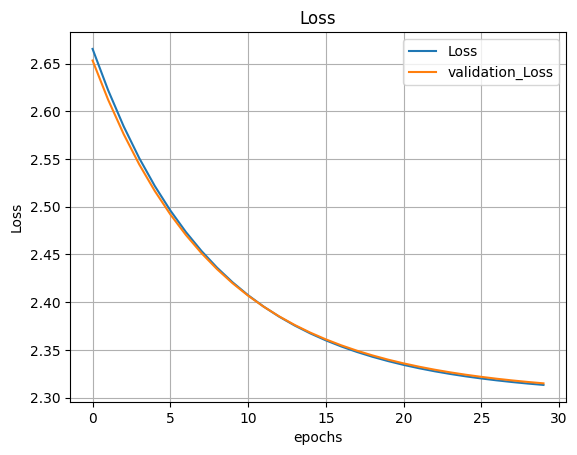

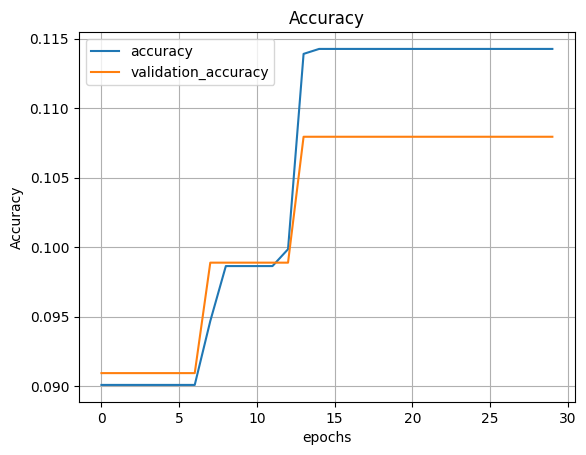

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


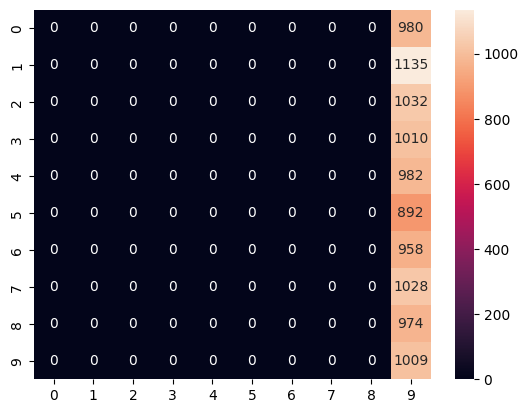

In [ ]:

#모델 평가
model.evaluate(x_test, t_test)

#모델 그래프
import matplotlib.pyplot as plt

# loss
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.grid()

plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label='validation_Loss')

plt.legend(loc='best')
plt.show()

# loss 그래프는 (출력층에 가까운 층만 가중치가 조금씩 조정되면서) 조금씩 줄어드는 모습,
#검증데이터와 훈련데이터의 숫자별 출현 빈도가 비슷해서 거의 비슷한 loss를 가지게됨.

#accuracy
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.grid()

plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label='validation_accuracy')

plt.legend(loc='best')
plt.show()

# accuracy 그래프는 처음엔 랜덤으로 맞추다가,
#뒷쪽 레이어가 업데이트 되면서 1로만 결과를 내니까 정확도가 조금 오르고(실제로 데이터에서 숫자1의 비율이 가장 높음),
#마지막으로는 이미지의 밝기나 실루엣 정도로 다른 숫자를 정해서 찍음(통게적으로 맞출 확률이 조금더 올라간다.)

#혼동행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

predicted_value=model.predict(x_test)
cm=confusion_matrix(np.argmax(t_test, axis=1),np.argmax(predicted_value,axis=-1)) #왼쪽에 들어간 값이 세로축, 오른쪽값이 가로축이 된다.
sns.heatmap(cm, annot=True, fmt='d')

plt.show()

original_t=np.argmax(t_test,axis=1)
label, counts=np.unique(original_t,return_counts=True) #데이터 안에 어떤 종류의 숫자가 있는지, 각각 몇개 들어있는지 보여줌

print('클래스 종류: ', label)
print('클래스별 개수: ', counts)
# 근데 원핫인코딩돼서 다시 풀어줘야 함.

# 혼동행렬 결과 -> 기울기 소실로 인해 출력층 근처 가중치들이 1만 선택하는 걸로 업데이트됨(loss를 가장 줄일 방법)

###도전1- 성공

In [ ]:
# 데이터 불러오기
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train, t_train), (x_test, t_test)= mnist.load_data()

print(np.unique(t_test, return_counts=True))

# 데이터 전처리- 이미지 데이터이므로 정규화, 원핫 인코딩
# 1) 정규화
x_train= x_train-0.0/255.0-0.0
x_test= x_test-0.0/255.0-0.0

#2) 원핫 인코딩
t_train=tf.keras.utils.to_categorical(t_train, num_classes=10)
t_test=tf.keras.utils.to_categorical(t_test, num_classes=10)

# 모델 구축
model1= tf.keras.Sequential()
model1.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model1.add(tf.keras.layers.Dense(128,activation='relu')) # 실수 - 문자열 매개변수는 소문자로!
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))
model1.add(tf.keras.layers.Dense(128,activation='relu'))

model1.add(tf.keras.layers.Dense(10,activation='softmax')) #실수 - softmax가 아닌 relu로 활성화 함수 사용.
model1.summary()

#모델 컴파일
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', 'recall', 'precision'])


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,866 (913.54 KB)

 Trainable params: 233,866 (913.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#모델 학습

hist=model1.fit(x_train, t_train, epochs=30, validation_split=0.3)



Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8077 - loss: 0.6362 - precision: 0.8757 - recall: 0.7619 - val_accuracy: 0.9037 - val_loss: 0.3093 - val_precision: 0.9237 - val_recall: 0.8877
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9305 - loss: 0.2303 - precision: 0.9440 - recall: 0.9192 - val_accuracy: 0.9361 - val_loss: 0.2117 - val_precision: 0.9484 - val_recall: 0.9263
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9523 - loss: 0.1579 - precision: 0.9612 - recall: 0.9453 - val_accuracy: 0.9467 - val_loss: 0.1868 - val_precision: 0.9543 - val_recall: 0.9403
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9639 - loss: 0.1187 - precision: 0.9705 - recall: 0.9586 - val_accuracy: 0.9511 - val_loss: 0.1655 - val_precision: 0.9578 - val_recall: 0.9445
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9720 - loss: 0.0906 - precision: 0.9767 - recall: 0.9681 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.1705 - precision: 0.9703 - recall: 0.9681


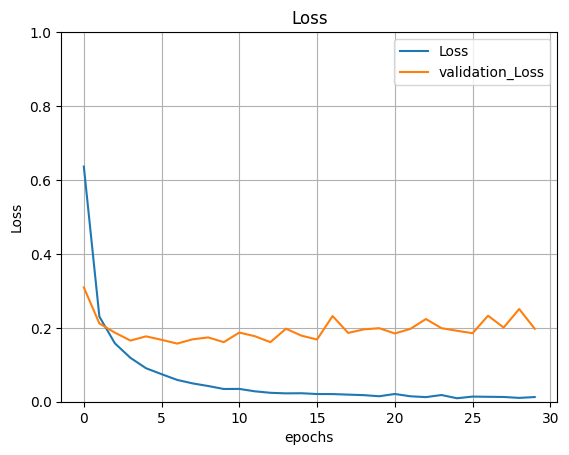

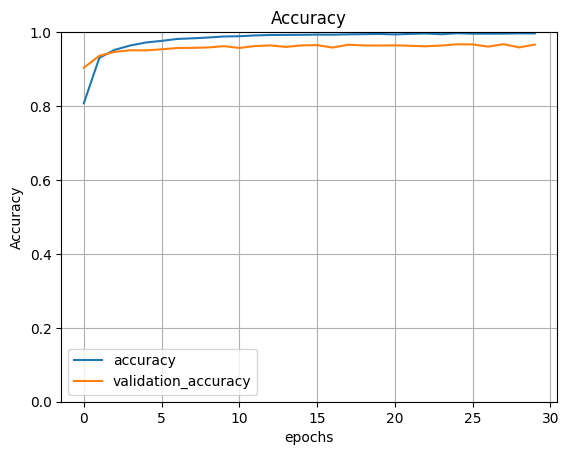

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


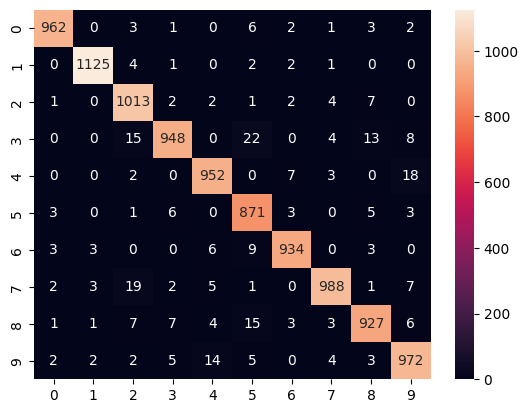

In [ ]:
import matplotlib.pyplot as plt
# 모델 평가
model1.evaluate(x_test, t_test) # 실수 - 데이터 안주고 평가시켜서 오류

#모델 그래프
#plt.figure(figsize=(8,8)) -> 굳이 없어도 됨(plt.show할때는)

# loss

plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.grid()

plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label='validation_Loss')
plt.ylim(0,1.0)

plt.legend(loc='best')
plt.show()

#accuracy

plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.grid()

plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label='validation_accuracy')
plt.ylim(0,1.0)

plt.legend(loc='best')
plt.show()

#혼동행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

predicted_value=model1.predict(x_test)
cm=confusion_matrix(np.argmax(t_test, axis=-1),np.argmax(predicted_value,axis=1))
sns.heatmap(cm, annot=True, fmt='d')

plt.show()


##도전2

###도전2- case A

In [ ]:
!pip install tensorflow

In [ ]:
# 데이터 불러오기 (1. 원본 데이터 가져오기, 2.문제X와 정답y로 나누기, 3. 학습할 데이터train, 테스트할 데이터 test를 나누기 )


import tensorflow as tf
from sklearn.datasets import load_breast_cancer #유방암 데이터셋을 가져오는 함수
from sklearn.model_selection import train_test_split #전체 데이터를 학습용과 테스트용으로 쪼개는 함수
cancer=load_breast_cancer()
# 위의 함수 실행후엔 데이터와 관련된 수많은 정보가 정리된 Bunch객체가 반환됨. 그 객체의 이름이 cancer가 됨.


# - 데이터 불러오기
X=cancer.data #입력 데이터는 30개의 상태정보. X는 행렬을 표시하기 위해 대문자로.
y=cancer.target #정답 레이블은 0(악성=암) 또는 1(양성). y는 벡터니까 소문자로.

feature_names=cancer.feature_names
print(feature_names)


# - 데이터 나누기(1. 전체의 80%를 훈련, 20%를 테스트 데이터로 나누기)
X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# random_state는 데이터를 나눌때 무작위로 섞는 기준(난수 초깃값)을 정해주는 매개변수.-> 데이터가 코드를 실행할 때마다 다르게 섞이는 걸 막아줌
# stratify는 데이터를 쪼갤 때 원래 데이터가 갖고 있던 0과 1의 비율을 유지하면서 분할해줌. stratify뒤에는 정답 배열을 줘야한다.
#그 데이터의 비율에 맞춰서 데이터를 나눠줌.

# - 데이터 나누기(2. 80%의 훈련 데이터에서, 다시 80%는 학습데이터로 20%는 검증데이터로 나누기)
X_train, X_val, y_train, y_val=train_test_split(
    X_train_tmp, y_train_tmp, test_size=0.2, random_state=42, stratify=y_train_tmp
)
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape, X_val.shape, y_val.shape)
print(X_train)


# ** 항상 딥러닝에서 데이터를 다룰때는 첫번째 자리가 데이터 개수, 두번째가 특징임.
# 만약, 3차원데이터(이미지)라면 데이터 갯수, 행 개수, 열 개수로 표현. **




# 데이터 전처리

# - 데이터 스케일링
from sklearn.preprocessing import StandardScaler #preprocessing은 사이킷런 라이브러리의 서브 패키지(전처리도구 모음).
scaler=StandardScaler() #StandardScaler 는 데이터를 평균0, 표준편차 1이 되도록 만드는 표준화 도구.

# 데이터 값의 단위가 컬럼별로 다르면, 단위가 큰 특징들의 가중치가 오차를 줄이는데 더 많이 조절되면서, 단위가 작은 특징들의 학습이 안될 수 있음.
#그래서 데이터 스케일링을 해줘야 함.


X_train= scaler.fit_transform(X_train) # Train 데이터의 평균, 표준편차를 계산하여 그 데이터를 평균0, 표편 1인 수치로 바꿈.
X_val=scaler.transform(X_val) #이미 만들어진 Train데이터 기준으로 변환.
X_test=scaler.transform(X_test)



['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
(364, 30) (364,) (114, 30) (114,) (91, 30) (91,)
[[1.480e+01 1.766e+01 9.588e+01 ... 8.308e-02 3.600e-01 7.285e-02]
 [1.174e+01 1.402e+01 7.424e+01 ... 8.290e-02 3.101e-01 6.688e-02]
 [1.471e+01 2.159e+01 9.555e+01 ... 1.834e-01 3.698e-01 1.094e-01]
 ...
 [1.444e+01 1.518e+01 9.397e+01 ... 1.599e-01 2.691e-01 7.683e-02]
 [1.742e+01 2.556e+01 1.145e+02 ... 1.099e-01 1.603e-01 6.818e-02]
 [1.143e+01 1.731e+01 7.366e+01 ... 6.402e-02 2.584e-01 

* **데이터 스케일링**: 데이터 값의 단위가 컬럼별로 다르면, 단위가 큰 특징들의 가중치가 오차를 줄이는데 더 많이 조절되면서, 단위가 작은 특징들의 학습이 안될 수 있음.->

* **preprocessing**(서브패키지)에 있는 도구(클래스)들

1. StandardScaler(모든 데이터의 평균과 표준편차를 0과 1로 조절하여 특징마다 다를 수 있는 단위를 표준화하는 도구)
2. MinMaxScaler(데이터의 최댓값과 최솟값을 이용해서 0~1사이 값으로 압축하는 도구, 이미지 처리에서 자주 사용)
3. OneHotEncoder/LabelEncoder(문자열 정답 데이터를 컴퓨터가 좋아하는 숫자형태로 바꿔주는 도구)



#### Case A

In [ ]:
# Case A

# 모델 구축
from tensorflow.keras.layers import Flatten, Dense
model1=tf.keras.Sequential()
model1.add(Flatten(input_shape=(30,)))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(10,activation='relu'))
model1.add(Dense(1, activation='sigmoid'))


#모델 컴파일
model1.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-2),
              loss='mse',
              metrics=['accuracy','precision','recall'])
model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431 (1.68 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#모델 학습-case A
hist1=model1.fit(X_train,y_train, validation_data=(X_val, y_val), epochs=30)
# fit() 함수는 첫번째에 학습문제, 두번째에 학습용 정답, 세번째에 batch_size를 받는다. 그래서 검증데이터라고 알려줘야 함.

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.6264 - loss: 0.2692 - precision: 0.6264 - recall: 1.0000 - val_accuracy: 0.6264 - val_loss: 0.2579 - val_precision: 0.6264 - val_recall: 1.0000
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6264 - loss: 0.2617 - precision: 0.6264 - recall: 1.0000 - val_accuracy: 0.6264 - val_loss: 0.2516 - val_precision: 0.6264 - val_recall: 1.0000
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6264 - loss: 0.2547 - precision: 0.6264 - recall: 1.0000 - val_accuracy: 0.6264 - val_loss: 0.2457 - val_precision: 0.6264 - val_recall: 1.0000
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6264 - loss: 0.2479 - precision: 0.6264 - recall: 1.0000 - val_accuracy: 0.6264 - val_loss: 0.2398 - val_precision: 0.6264 - val_recall: 1.0000
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6264 - loss: 0.2414 - precision: 0.6264 - recall: 1.0000 - val_accuracy: 0.6264 - val_loss: 0.2342 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8772 - loss: 0.1514 - precision: 0.8372 - recall: 1.0000


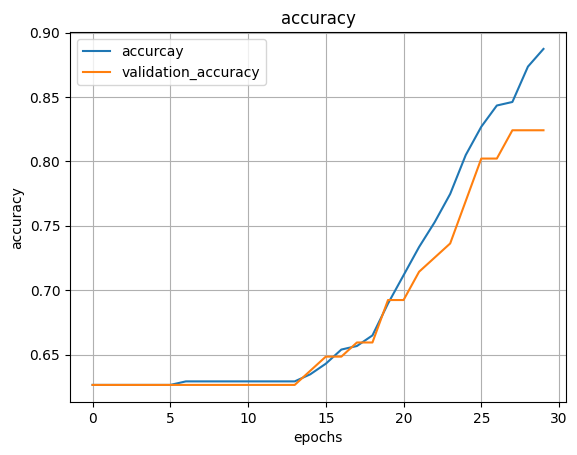

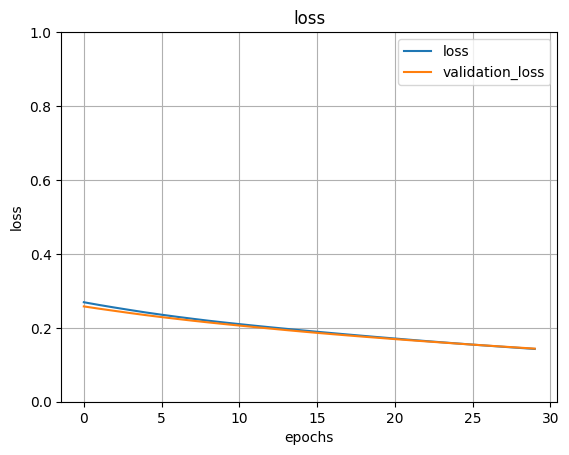

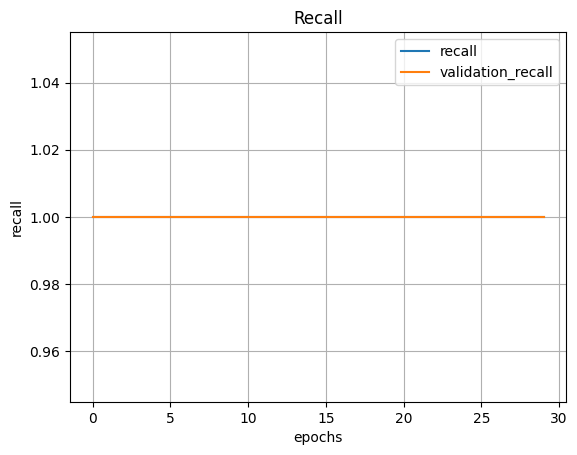

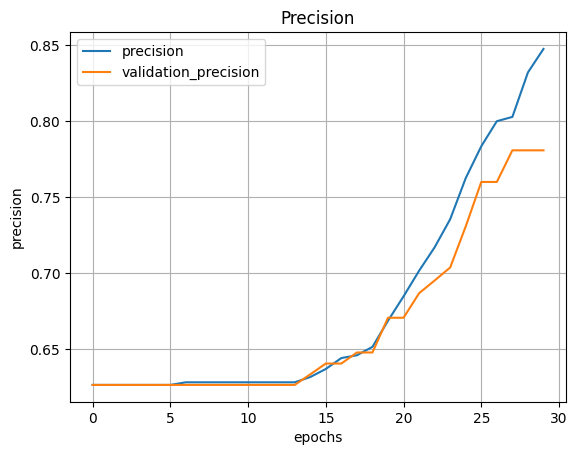

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


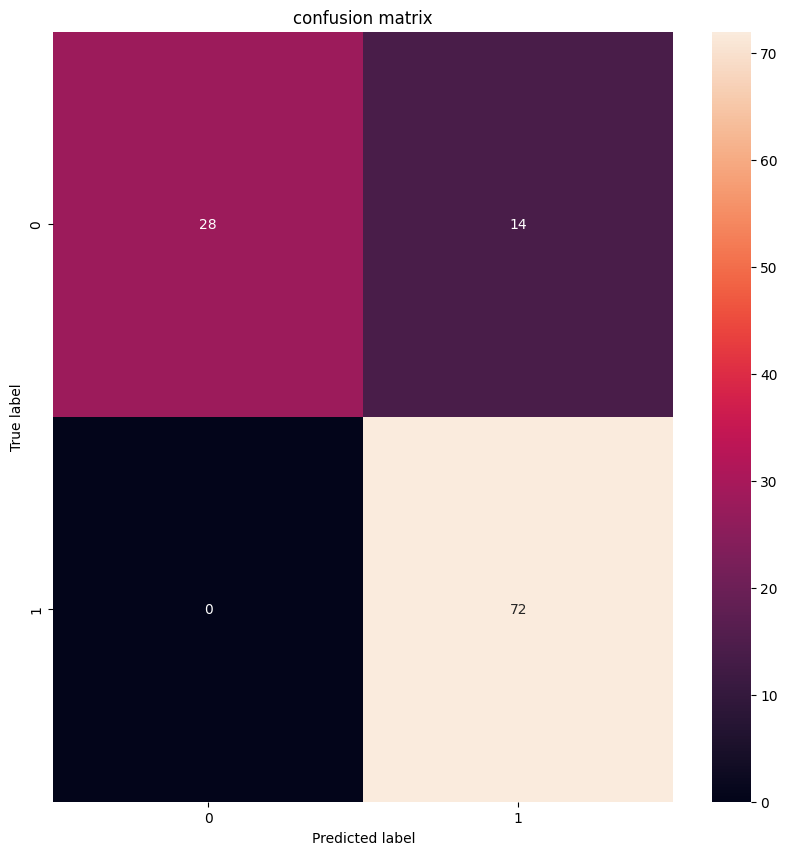

In [ ]:
#모델 평가 & 그래프그리기 -Case A
model1.evaluate(X_test, y_test)

import matplotlib.pyplot as plt
# accuracy 그래프
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.plot(hist1.history['accuracy'],label='accurcay')
plt.plot(hist1.history['val_accuracy'], label='validation_accuracy')

plt.legend(loc='best')
plt.grid()
plt.show()

#loss 그래프
plt.title('loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.ylim(0.0, 1.0)

plt.plot(hist1.history['loss'], label='loss')
plt.plot(hist1.history['val_loss'], label='validation_loss')

plt.legend(loc='best')
plt.grid()
plt.show()

# recall 그래프
plt.title('Recall')
plt.xlabel('epochs')
plt.ylabel('recall')

plt.plot(hist1.history['recall'], label='recall')
plt.plot(hist1.history['val_recall'], label='validation_recall')

plt.legend(loc='best')
plt.grid()
plt.show()

# precision 그래프
plt.title('Precision')
plt.xlabel('epochs')
plt.ylabel('precision')

plt.plot(hist1.history['precision'], label='precision')
plt.plot(hist1.history['val_precision'], label='validation_precision')

plt.legend(loc='best')
plt.grid()
plt.show()

#혼동행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,10))
predicted_value=model1.predict(X_test)
# 예측값의 형태가 시그모이드를 통과한 후라서 0과 1사이의 값임-> 0또는 1로 바꿔주기(반올림).
predicted_value=np.round(predicted_value)
cm=confusion_matrix(y_test, predicted_value) #가로축: 모델의 예측, 세로축: 실제 정답-> 순서는 정답, 예측순으로 넣기!

sns.heatmap(cm,annot=True, fmt='d')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('confusion matrix')
plt.show()


##### 그래프 해석 - case A
1) loss: 오차의 최대 크기가 1이고, mse도 제곱하는 거라 결론적으로 오차의 전체 값이 그렇게 크지 않다. 그래서 작은 값에서 시작하는 거임.
2) recall: "시그모이드 + mse" 조합으로 인해 기울기 소실이 발생하여 모델이 전부 1(악성)로 찍는 상태가 됨. 학습 내내 그 상태에서 벗어나지 못하게 되어서, validation_recall 과 recall 모두 1이 나왔고 그래프 상에는 겹쳐있는 거임(recall =모델이 악성으로 예측한 갯수/실제 악성 갯수).

####case B

In [ ]:
# Case B

#모델 구축
from tensorflow.keras.layers import Flatten, Dense
model2=tf.keras.Sequential()
model2.add(Flatten(input_shape=(30,)))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.summary()

model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-2),
               loss='binary_crossentropy',
               metrics=['accuracy', 'recall','precision'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431 (1.68 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#모델 학습-case B
hist2=model2.fit(X_train,y_train, validation_data=(X_val, y_val), epochs=30)
# fit() 함수는 첫번째에 학습문제, 두번째에 학습용 정답, 세번째에 batch_size를 받는다. 그래서 검증데이터라고 알려줘야 함.

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6813 - loss: 0.4964 - precision: 0.6628 - recall: 1.0000 - val_accuracy: 0.6923 - val_loss: 0.4963 - val_precision: 0.6706 - val_recall: 1.0000
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7280 - loss: 0.4703 - precision: 0.6972 - recall: 1.0000 - val_accuracy: 0.7253 - val_loss: 0.4754 - val_precision: 0.6951 - val_recall: 1.0000
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7555 - loss: 0.4470 - precision: 0.7206 - recall: 0.9956 - val_accuracy: 0.7473 - val_loss: 0.4535 - val_precision: 0.7125 - val_recall: 1.0000
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8104 - loss: 0.4250 - precision: 0.7695 - recall: 0.9956 - val_accuracy: 0.7912 - val_loss: 0.4324 - val_precision: 0.7500 - val_recall: 1.0000
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8434 - loss: 0.4032 - precision: 0.8043 - recall: 0.9912 - val_accuracy: 0.8022 - val_loss: 0.4127 - va

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9386 - loss: 0.1936 - precision: 0.9452 - recall: 0.9583


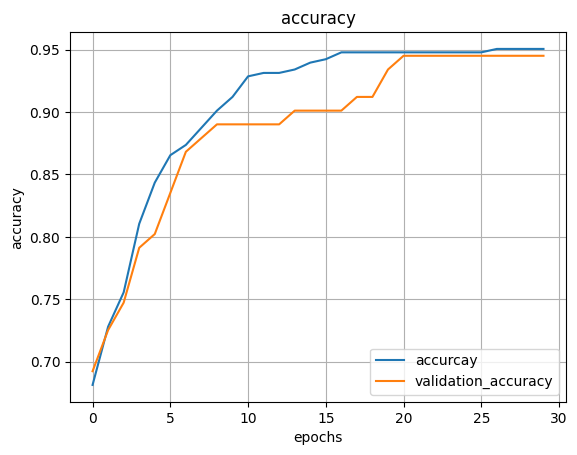

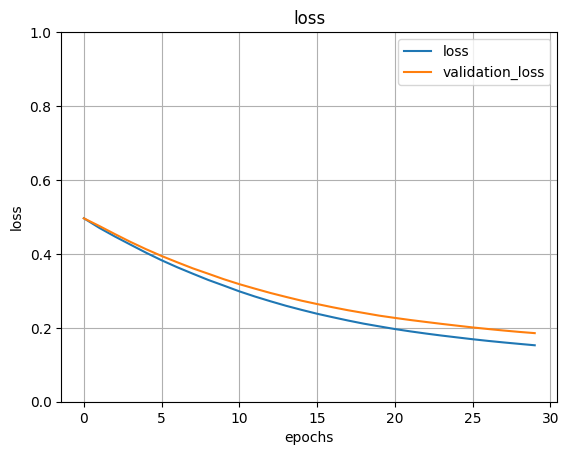

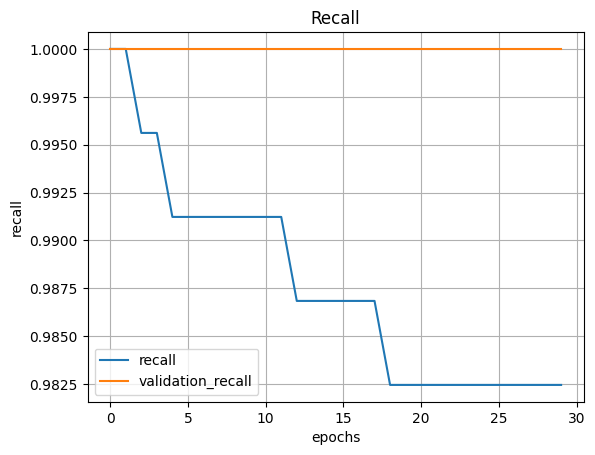

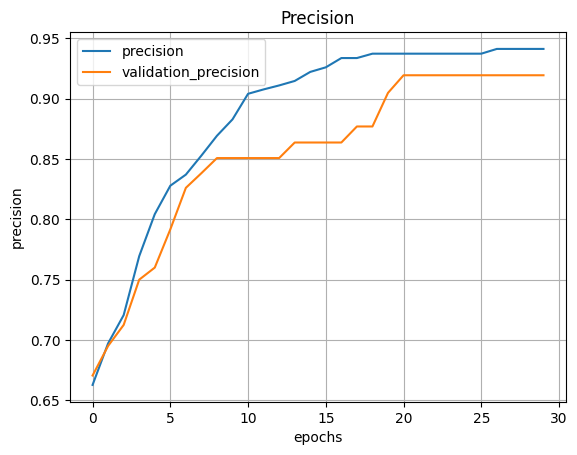

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


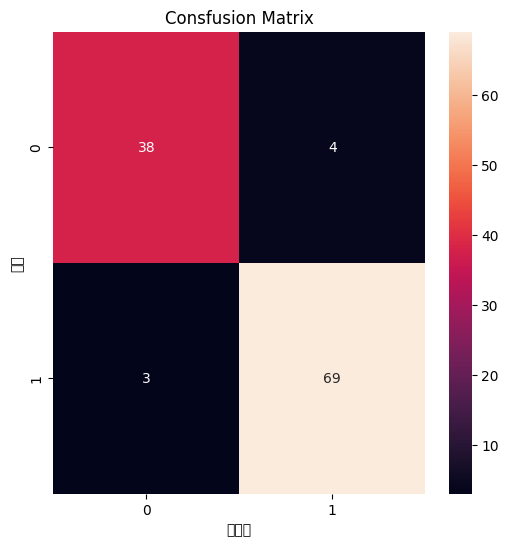

In [ ]:
#모델 평가 & 그래프그리기 - Case B
model2.evaluate(X_test, y_test)

import matplotlib.pyplot as plt
# accuracy 그래프
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.plot(hist2.history['accuracy'],label='accurcay')
plt.plot(hist2.history['val_accuracy'], label='validation_accuracy')

plt.legend(loc='best')
plt.grid()
plt.show()

#loss 그래프
plt.title('loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.ylim(0.0, 1.0)
plt.plot(hist2.history['loss'], label='loss')
plt.plot(hist2.history['val_loss'], label='validation_loss')

plt.legend(loc='best')
plt.grid()
plt.show()

# recall 그래프
plt.title('Recall')
plt.xlabel('epochs')
plt.ylabel('recall')

plt.plot(hist2.history['recall'], label='recall')
plt.plot(hist2.history['val_recall'], label='validation_recall')

plt.legend(loc='best')
plt.grid()
plt.show()

# precision 그래프
plt.title('Precision')
plt.xlabel('epochs')
plt.ylabel('precision')

plt.plot(hist2.history['precision'], label='precision')
plt.plot(hist2.history['val_precision'], label='validation_precision')

plt.legend(loc='best')
plt.grid()
plt.show()

#혼동행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,6))
predicted_value=model2.predict(X_test)
predicted_value=np.round(predicted_value)
cm=confusion_matrix(y_test, predicted_value)
sns.heatmap(cm, fmt='d',annot=True )
plt.title('Consfusion Matrix')
plt.xlabel('predicted')
plt.ylabel('Target')
plt.show()



##### 그래프 해석 - case B
1) loss: 로그 함수를 사용하기 때문에 모델이 틀린 답을 확신할수록 오차가 무한대까지 치솟음. 그래서 case A보다 높은 값으로 시작.
2) recall: 처음엔 얘도 전부 1로 찍다가 (BCE는 미분값도 mse보다 더 큰 값이 나오니까) 기울기 소실을 피하고 모델이 학습을 통해서 제대로 된 실력(전부 1로 찍는게 아닌 1과 0을 판단)을 갖춰가는 거임.
또 훈련데이터에서 0과 1을 구분하기 시작했어도 validation data에서는 자신이 없어서 여전히 1로 다 찍기 때문에 validation_recall이 계속 1인거임(epoch이 늘어나면 얘도 정상수치로 떨어짐-> Case C).
3) recall값이 떨어진다고 성능이 떨어지는 게 아니라(0.9 근방에서 머물고 있기에) 오히려 똑똑한 모델이 되어가는 중임.-> precision도 올라간다.

** 왜 처음부터 적극적으로 학습을 하지 않고 1로 찍어서 recall이 처음에 거의 변동이 없는걸까? 처음이 오히려 오차가 크니까 변동이 커야 하는 거 아닌가?

- 옵티마이저의 꼼수 : 처음에 모든 데이터에 대해 비슷한 확률(0.5)을 출력한뒤(무작위 가중치 초기화), 각 데이터 마다의 손실값으로 구한 평균을 경사하강법 업데이트에 이용한다.(그 결과 대부분의 데이터 예측값이 비슷하게 나옴.)



**- 첫번째 수학적 원리**

1. 이때 **전체 데이터의 불균형**이 어느 한 방향으로 bias를 이끌게 됨(데이터의 정답이 특정 클래스에 몰린 경우, 학습하면 그 클래스가 정답이 되게끔 하는 쪽으로 오차값이 나옴).


**- 두번째 수학적 원리**

1. **일반적인 가중치**(w)에는 x(입력값)가 곱해지기에 기울기들이 x의 크기나 부호에 따라 서로 상쇄 되거나 감쇄될 수 있다(미니배치의 경우, 오차에 대한 가중치의 기울기는 배치안의 모든 데이터 각각의 오차에 대한 가중치로 미분한 값들의 합이 된다. 따라서 같은 배치안에 있는 입력값들이 서로 반대 방향이거나, 1보다 작은 값을 가진다면 오차를 더 적게 반영하게 됨).


2. 하지만 **바이어스**(w)는 항상 입력값이 1로 일정해서 업데이트 시, 오차값이 상대적으로 크게 반영된다. 그래서 겉으로 보기에는 모델이 바이어스를 먼저 건드리는 것 처럼 보인다.


-> 그 뒤에 mse는 기울기 소실로 인해 학습 안 되지만, BCE는 기울기 소실을 피함으로써 다른 가중치들도 학습하게 됨.

In [ ]:
# Case C

#모델 구축
from tensorflow.keras.layers import Flatten, Dense
model3=tf.keras.Sequential()
model3.add(Flatten(input_shape=(30,)))
model3.add(Dense(10, activation='relu'))
model3.add(Dense(10, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

model3.summary()

model3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-2),
               loss='binary_crossentropy',
               metrics=['accuracy', 'recall','precision'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431 (1.68 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#모델 학습-case C
hist3=model3.fit(X_train,y_train, validation_data=(X_val, y_val), epochs=60)
# fit() 함수는 첫번째에 학습문제, 두번째에 학습용 정답, 세번째에 batch_size를 받는다. 그래서 검증데이터라고 알려줘야 함.

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.3626 - loss: 0.7656 - precision: 0.4737 - recall: 0.1579 - val_accuracy: 0.3956 - val_loss: 0.7194 - val_precision: 0.5625 - val_recall: 0.1579
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4945 - loss: 0.6664 - precision: 0.7558 - recall: 0.2851 - val_accuracy: 0.4945 - val_loss: 0.6486 - val_precision: 0.7619 - val_recall: 0.2807
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6374 - loss: 0.6029 - precision: 0.8871 - recall: 0.4825 - val_accuracy: 0.6484 - val_loss: 0.5969 - val_precision: 0.8571 - val_recall: 0.5263
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7555 - loss: 0.5569 - precision: 0.9371 - recall: 0.6535 - val_accuracy: 0.7582 - val_loss: 0.5592 - val_precision: 0.9070 - val_recall: 0.6842
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8242 - loss: 0.5210 - precision: 0.9457 - recall: 0.7632 - val_accuracy: 0.8132 - val_loss: 0.5261 -

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9649 - loss: 0.1294 - precision: 0.9722 - recall: 0.9722


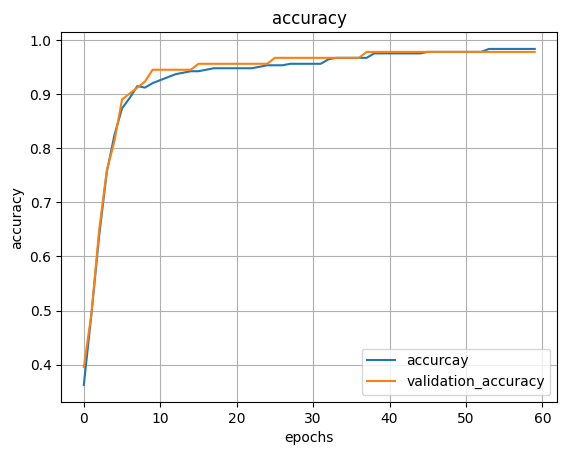

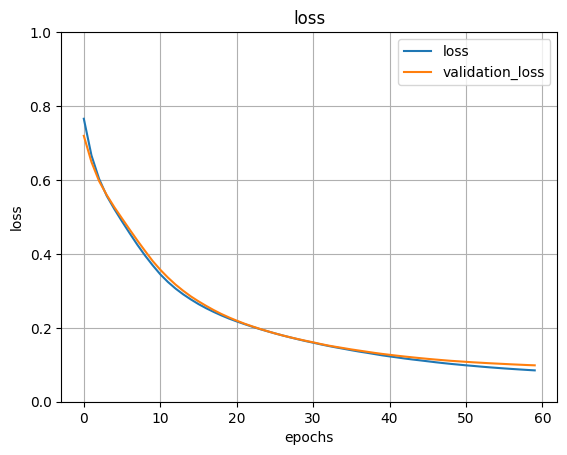

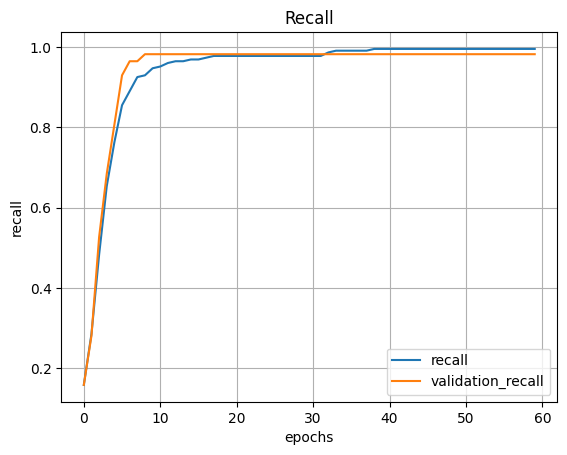

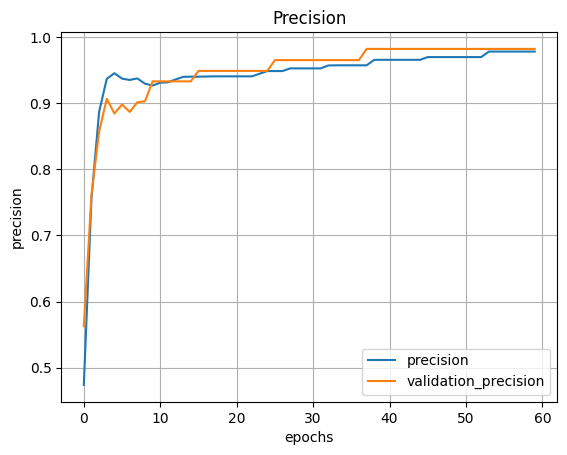

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


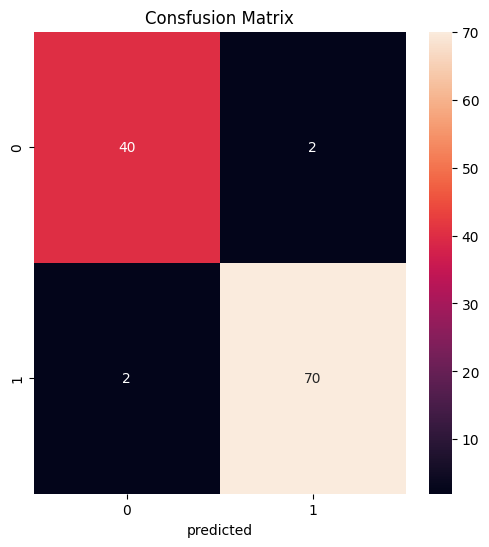

In [ ]:
#모델 평가 & 그래프그리기 - Case C
model3.evaluate(X_test, y_test)

import matplotlib.pyplot as plt
# accuracy 그래프
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.plot(hist3.history['accuracy'],label='accurcay')
plt.plot(hist3.history['val_accuracy'], label='validation_accuracy')

plt.legend(loc='best')
plt.grid()
plt.show()

#loss 그래프
plt.title('loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.ylim(0.0, 1.0)
plt.plot(hist3.history['loss'], label='loss')
plt.plot(hist3.history['val_loss'], label='validation_loss')

plt.legend(loc='best')
plt.grid()
plt.show()

# recall 그래프
plt.title('Recall')
plt.xlabel('epochs')
plt.ylabel('recall')

plt.plot(hist3.history['recall'], label='recall')
plt.plot(hist3.history['val_recall'], label='validation_recall')

plt.legend(loc='best')
plt.grid()
plt.show()

# precision 그래프
plt.title('Precision')
plt.xlabel('epochs')
plt.ylabel('precision')

plt.plot(hist3.history['precision'], label='precision')
plt.plot(hist3.history['val_precision'], label='validation_precision')

plt.legend(loc='best')
plt.grid()
plt.show()

#혼동행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,6))
predicted_value=model3.predict(X_test)
predicted_value=np.round(predicted_value)
cm=confusion_matrix(y_test, predicted_value)
sns.heatmap(cm, fmt='d',annot=True )
plt.title('Consfusion Matrix')
plt.xlabel('predicted')
plt.ylabel('')
plt.show()



##도전 3

###도전 3

In [ ]:
** 코드 해석부터

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# 데이터 불러오기 - shape확인, 값 확인, 문제와 정답 분리하기(-> 그리고 학습/검증/테스트용으로 나누기)

## 0. 구글 드라이브 마운트 하기 -> 임시 업로드로 대체

## 1. csv파일 불러오기
df= pd.read_csv('creditcard.csv')
print(df.head())

## 2. 데이터 구조 살펴보기
print('데이터 크기: ', df.shape)
print('\n[정답 클래스 분포(0: 정상, 1: 사기)]')
print(df['Class'].value_counts())

## 3.문제와 정답 분리하기
X=df.drop(columns=['Class']).values
y=df['Class'].values

## 4. 학습/검증/테스트용 나누기
X_train_tmp, y_train_tmp, X_test, y_test=train_test_split(  #근데 여기서 데이터 순서 바꿔쓰면 안되나?
    X,y,test_size=0.2, random_state=42, stratify=y
)
X_train, y_train, X_validation, y_validation=train_test_split(
    X_train_tmp, y_train_tmp, test_size= 0.2, random_state=42, stratify=y_train_tmp #test_size 라고 써도 validation size가 되는건가?
)
## 5. 최종 분할된 데이터 확인
print('\n[최종 데이터 분할 결과]')
print(f'X_train: {X_train.shape},y_train: {y_train.shape}')

# 데이터 전처리 - 표준화(특징별). 정규화(전체), 원핫 인코딩(CCE니까), 데이터 나누기(validation_data)

# 모델 구축 - 마지막 층은 클래스 갯수만큼 노드수 맞추기(마지막 softmax)

# 모델 컴파일 - accuracy, recall, loss, 모두.(CCE, RMSprop)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

ValueError: Found input variables with inconsistent numbers of samples: [227845, 56962]

In [ ]:
# 모델 학습 - epoch, 검증데이터 넣기

In [ ]:
# 모델 평가 - accuracy, recall, loss, precision 그래프 모두 그리기 + 혼동행렬